## Similitud de documentos mediante Bag-of-Words y TF-IDF

En esta práctica se analiza la similitud entre 12 documentos relacionados con tecnología móvil y vehículos eléctricos. Para ello se utilizan representaciones Bag-of-Words y TF-IDF, calculando posteriormente la similitud del coseno mediante PyTorch.

### 1. Carga de librerías

Se importan las librerías necesarias para la lectura y procesamiento de los documentos, el preprocesamiento del texto, la construcción de las representaciones vectoriales con PyTorch y la visualización de los resultados.

In [1]:
from pathlib import Path
from docx import Document
import re

import nltk
from nltk.corpus import stopwords

import torch
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt

### 2. Lectura de datos

Se cargan automáticamente los documentos `.docx` almacenados en la carpeta `data` y se extrae su contenido textual para poder procesarlo posteriormente.

In [2]:
DATA_DIR = Path("data")
document_paths = sorted(DATA_DIR.glob("doc*.docx"))

def read_docx(path):
    document = Document(path)

    paragraphs = [
        paragraph.text
        for paragraph in document.paragraphs
        if paragraph.text.strip()
    ]

    return " ".join(paragraphs)

documents = [read_docx(path) for path in document_paths]
document_names = [path.stem for path in document_paths]

print(f"Documentos cargados: {len(documents)}")
print(f"\nEjemplo ({document_names[0]}):")
print(documents[0][:500] + "...")


Documentos cargados: 12

Ejemplo (doc01):
Nuevo smartphone de alta gama promete revolucionar el mercado Hoy se anunció el lanzamiento del último smartphone de la reconocida marca Tecnophone. Este nuevo dispositivo, denominado Tecnophone XZ, promete características sobresalientes que seguramente causarán revuelo en la industria móvil. Incorpora una pantalla OLED de 6.7 pulgadas, un procesador de última generación y una memoria RAM de 12 GB. Además, para los amantes de la fotografía, el Tecnophone XZ posee una cámara triple con una resolu...


### 3. Preprocesamiento y stop-words

Los documentos se normalizan convirtiendo el texto a minúsculas, eliminando caracteres no alfabéticos y separándolo en palabras. Además, se eliminan las stopwords del español proporcionadas por NLTK, ya que son palabras muy frecuentes que normalmente aportan poca información para distinguir entre documentos.

In [3]:
nltk.download("stopwords", quiet=True)

substitutions = str.maketrans(
    "áéíóúü",
    "aeiouu"
)

stop_words = {
    word.translate(substitutions)
    for word in stopwords.words("spanish")
}

print(f"Número de stopwords: {len(stop_words)}")

Número de stopwords: 306


In [4]:
def preprocess_text(text):
    text = text.lower()
    text = text.translate(substitutions)
    tokens = re.findall(r"[a-zñ]+", text)

    tokens = [
        token
        for token in tokens
        if token not in stop_words
    ]

    return tokens


processed_documents = [
    preprocess_text(document)
    for document in documents
]

print(processed_documents[0][:30])

['nuevo', 'smartphone', 'alta', 'gama', 'promete', 'revolucionar', 'mercado', 'hoy', 'anuncio', 'lanzamiento', 'ultimo', 'smartphone', 'reconocida', 'marca', 'tecnophone', 'nuevo', 'dispositivo', 'denominado', 'tecnophone', 'xz', 'promete', 'caracteristicas', 'sobresalientes', 'seguramente', 'causaran', 'revuelo', 'industria', 'movil', 'incorpora', 'pantalla']


La expresión regular r"[a-zñ]+" permite conservar únicamente secuencias de caracteres alfabéticos, eliminando números y signos de puntuación.

### 4. Construcción del vocabulario

A partir de los documentos preprocesados se construye un vocabulario global formado por todas las palabras únicas del corpus. A cada término se le asigna un índice que posteriormente determinará su posición en los vectores Bag-of-Words.

In [5]:
vocabulary = sorted({
    token
    for document in processed_documents
    for token in document
})

print("Tamaño del vocabulario:", len(vocabulary))
print(vocabulary[:30])

word_to_index = {
    word: index
    for index, word in enumerate(vocabulary)
}

Tamaño del vocabulario: 408
['actualizaciones', 'ademas', 'adopcion', 'adquisicion', 'afirman', 'agigantados', 'ahora', 'alta', 'amantes', 'ambas', 'amenazas', 'anunciado', 'anuncio', 'aplicacion', 'aplicaciones', 'aporta', 'app', 'apps', 'aprovechar', 'aquellos', 'ar', 'arduamente', 'areas', 'arworld', 'asequible', 'auge', 'aumentada', 'aumentando', 'aumento', 'autenticacion']


### 5. Construcción del Bag-of-Words

Cada documento se representa mediante un vector Bag-of-Words. Cada posición corresponde a una palabra del vocabulario y su valor indica el número de veces que dicha palabra aparece en el documento.

In [6]:
bow_matrix = torch.zeros(
    (len(processed_documents), len(vocabulary)),
    dtype=torch.float32
)

print(bow_matrix.shape)


for document_index, tokens in enumerate(processed_documents):

    for token in tokens:

        word_index = word_to_index[token]
        bow_matrix[document_index, word_index] += 1

doc_index = 0

for word, index in word_to_index.items():
    frequency = bow_matrix[doc_index, index].item()

    if frequency > 0:
        print(f"{word}: {int(frequency)}")

torch.Size([12, 408])
ademas: 1
alta: 1
amantes: 1
anuncio: 1
año: 1
calificado: 1
camara: 1
caracteristicas: 1
causaran: 1
denominado: 1
dispositivo: 1
esperan: 1
expertos: 1
fotografia: 1
gama: 1
gb: 1
generacion: 1
hoy: 1
impacto: 1
incorpora: 1
industria: 1
lanzamiento: 1
marca: 1
megapixeles: 1
memoria: 1
mercado: 2
meses: 1
movil: 2
nuevo: 2
oled: 1
pantalla: 1
posee: 1
procesador: 1
promete: 2
proximos: 1
pulgadas: 1
ram: 1
reconocida: 1
resolucion: 1
revolucionar: 1
revuelo: 1
seguramente: 1
smartphone: 2
sobresalientes: 1
tecnophone: 3
triple: 1
ultima: 1
ultimo: 1
ver: 1
xz: 2


### 6. Similitud del coseno

A partir de los vectores Bag-of-Words se calcula la similitud del coseno entre los documentos. Esta métrica permite medir el parecido entre sus representaciones vectoriales independientemente de su magnitud.

In [7]:
similarity = F.cosine_similarity(
    bow_matrix[0].unsqueeze(0),
    bow_matrix[1].unsqueeze(0)
)

print(similarity.item())


similarity_matrix = F.cosine_similarity(
    bow_matrix.unsqueeze(1),
    bow_matrix.unsqueeze(0),
    dim=2
)

print(similarity_matrix.shape)

0.04442616552114487
torch.Size([12, 12])


### 7. Mostrar y analizar la matriz de similitud

La matriz de similitud permite observar el grado de semejanza entre cada par de documentos. A continuación, se extraen y ordenan las parejas para identificar cuáles presentan mayor y menor similitud.

In [8]:
similarity_df = pd.DataFrame(
    similarity_matrix.numpy(),
    index=document_names,
    columns=document_names
)

similarity_df.round(3)

,doc01,doc02,doc03,doc04,doc05,doc06,doc07,doc08,doc09,doc10,doc11,doc12
doc01,1.000,0.044,0.000,0.080,0.099,0.138,0.064,0.015,0.000,0.050,0.157,0.089
doc02,0.044,1.000,0.096,0.000,0.000,0.104,0.125,0.034,0.000,0.112,0.203,0.100
doc03,0.000,0.096,1.000,0.000,0.000,0.033,0.103,0.016,0.000,0.090,0.000,0.053
doc04,0.080,0.000,0.000,1.000,0.100,0.074,0.058,0.129,0.217,0.000,0.136,0.251
doc05,0.099,0.000,0.000,0.100,1.000,0.058,0.000,0.191,0.207,0.042,0.113,0.062
doc06,0.138,0.104,0.033,0.074,0.058,1.000,0.130,0.035,0.017,0.077,0.131,0.104
doc07,0.064,0.125,0.103,0.058,0.000,0.130,1.000,0.018,0.000,0.060,0.190,0.155
doc08,0.015,0.034,0.016,0.129,0.191,0.035,0.018,1.000,0.086,0.019,0.091,0.034
doc09,0.000,0.000,0.000,0.217,0.207,0.017,0.000,0.086,1.000,0.038,0.166,0.325
doc10,0.050,0.112,0.090,0.000,0.042,0.077,0.060,0.019,0.038,1.000,0.071,0.087


In [9]:
similarity_pairs = []

num_documents = len(document_names)

for i in range(num_documents):

    for j in range(i + 1, num_documents):

        similarity_pairs.append(
            (
                document_names[i],
                document_names[j],
                similarity_matrix[i, j].item()
            )
        )

Se comienza en `i + 1` para evitar comparar cada documento consigo mismo y para no repetir parejas equivalentes como `doc01-doc02` y `doc02-doc01`.

In [10]:
similarity_pairs.sort(
    key=lambda pair: pair[2],
    reverse=True
)

print("Documentos más similares:\n")

for doc1, doc2, similarity in similarity_pairs[:5]:
    print(f"{doc1} - {doc2}: {similarity:.3f}")

Documentos más similares:

doc09 - doc12: 0.325
doc11 - doc12: 0.304
doc04 - doc12: 0.251
doc04 - doc09: 0.217
doc05 - doc09: 0.207


In [11]:
print("Documentos menos similares:\n")

for doc1, doc2, similarity in similarity_pairs[-5:]:
    print(f"{doc1} - {doc2}: {similarity:.3f}")

Documentos menos similares:

doc03 - doc09: 0.000
doc03 - doc11: 0.000
doc04 - doc10: 0.000
doc05 - doc07: 0.000
doc07 - doc09: 0.000


### 8. Visualización

Se representa gráficamente la matriz de similitud para facilitar la identificación visual de los documentos y grupos que presentan mayor semejanza.

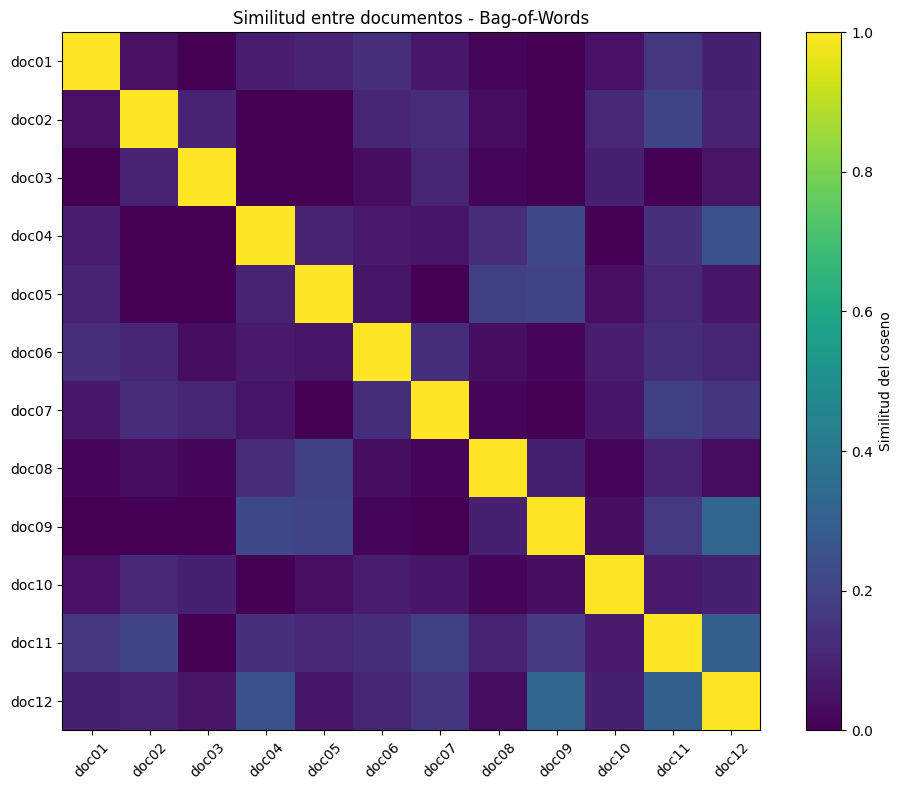

In [12]:
plt.figure(figsize=(10, 8))

plt.imshow(similarity_matrix.numpy())

plt.colorbar(label="Similitud del coseno")

plt.xticks(
    range(len(document_names)),
    document_names,
    rotation=45
)

plt.yticks(
    range(len(document_names)),
    document_names
)

plt.title("Similitud entre documentos - Bag-of-Words")

plt.tight_layout()
plt.show()

### 9. Cálculo de TF y frecuencia documental

Para construir la representación TF-IDF se calcula primero la frecuencia relativa de cada término dentro de cada documento (TF) y el número de documentos del corpus en los que aparece cada término (frecuencia documental).

In [13]:
document_lengths = bow_matrix.sum(
    dim=1,
    keepdim=True
)

tf_matrix = bow_matrix / document_lengths

document_frequency = (
    bow_matrix > 0
).sum(dim=0)

### 10. IDF

Se calcula la frecuencia inversa de documento (IDF), que reduce el peso de las palabras que aparecen en muchos documentos y aumenta la importancia relativa de los términos menos frecuentes en el corpus.

In [14]:
num_documents = bow_matrix.shape[0]

idf = torch.log(
    num_documents / document_frequency
)

Finalmente, se obtiene la representación TF-IDF multiplicando la frecuencia de cada término por su frecuencia inversa de documento.

In [15]:
tfidf_matrix = tf_matrix * idf

### 11. Similitud TF-IDF

Se vuelve a calcular la similitud del coseno utilizando ahora las representaciones TF-IDF, lo que permite comparar estos resultados con los obtenidos mediante Bag-of-Words.

In [16]:
tfidf_similarity_matrix = F.cosine_similarity(
    tfidf_matrix.unsqueeze(1),
    tfidf_matrix.unsqueeze(0),
    dim=2
)

tfidf_similarity_df = pd.DataFrame(
    tfidf_similarity_matrix.numpy(),
    index=document_names,
    columns=document_names
)

tfidf_similarity_df.round(3)

,doc01,doc02,doc03,doc04,doc05,doc06,doc07,doc08,doc09,doc10,doc11,doc12
doc01,1.000,0.008,0.000,0.035,0.052,0.057,0.004,0.011,0.000,0.013,0.041,0.017
doc02,0.008,1.000,0.065,0.000,0.000,0.026,0.028,0.016,0.000,0.040,0.074,0.033
doc03,0.000,0.065,1.000,0.000,0.000,0.015,0.057,0.012,0.000,0.041,0.000,0.024
doc04,0.035,0.000,0.000,1.000,0.026,0.028,0.032,0.057,0.069,0.000,0.049,0.092
doc05,0.052,0.000,0.000,0.026,1.000,0.020,0.000,0.072,0.070,0.018,0.046,0.016
doc06,0.057,0.026,0.015,0.028,0.020,1.000,0.027,0.008,0.003,0.010,0.026,0.028
doc07,0.004,0.028,0.057,0.032,0.000,0.027,1.000,0.003,0.000,0.005,0.036,0.038
doc08,0.011,0.016,0.012,0.057,0.072,0.008,0.003,1.000,0.025,0.013,0.034,0.024
doc09,0.000,0.000,0.000,0.069,0.070,0.003,0.000,0.025,1.000,0.017,0.072,0.134
doc10,0.013,0.040,0.041,0.000,0.018,0.010,0.005,0.013,0.017,1.000,0.006,0.016


Para facilitar la comparación, se define una función que obtiene y ordena las parejas de documentos según su similitud.

In [17]:
def get_similarity_pairs(similarity_matrix, document_names):

    pairs = []

    num_documents = len(document_names)

    for i in range(num_documents):

        for j in range(i + 1, num_documents):

            pairs.append(
                (
                    document_names[i],
                    document_names[j],
                    similarity_matrix[i, j].item()
                )
            )

    return sorted(
        pairs,
        key=lambda pair: pair[2],
        reverse=True
    )

In [18]:
bow_pairs = get_similarity_pairs(
    similarity_matrix,
    document_names
)

tfidf_pairs = get_similarity_pairs(
    tfidf_similarity_matrix,
    document_names
)

Se muestran los documentos más similares con ambos métodos para observar cómo cambia el resultado al ponderar la importancia de las palabras mediante TF-IDF.

In [19]:
print("TOP 5 - Bag-of-Words")
print("-" * 30)

for doc1, doc2, similarity in bow_pairs[:5]:
    print(f"{doc1} - {doc2}: {similarity:.3f}")


print("\nTOP 5 - TF-IDF")
print("-" * 30)

for doc1, doc2, similarity in tfidf_pairs[:5]:
    print(f"{doc1} - {doc2}: {similarity:.3f}")

TOP 5 - Bag-of-Words
------------------------------
doc09 - doc12: 0.325
doc11 - doc12: 0.304
doc04 - doc12: 0.251
doc04 - doc09: 0.217
doc05 - doc09: 0.207

TOP 5 - TF-IDF
------------------------------
doc09 - doc12: 0.134
doc11 - doc12: 0.119
doc04 - doc12: 0.092
doc02 - doc11: 0.074
doc05 - doc08: 0.072


### 12. Conclusiones

Los resultados obtenidos muestran que tanto Bag-of-Words como TF-IDF permiten identificar relaciones temáticas entre los documentos a partir del vocabulario que comparten.

Con Bag-of-Words, el par con mayor similitud es `doc09-doc12`, con un valor de 0.325, seguido de `doc11-doc12` con 0.304 y `doc04-doc12` con 0.251. Estos resultados son coherentes con el contenido de los documentos, ya que `doc12` combina aspectos relacionados con tecnología móvil y vehículos eléctricos, por lo que comparte vocabulario con documentos de ambas temáticas. En particular, su elevada similitud con `doc09` se explica por la presencia de términos relacionados con la carga y la infraestructura para vehículos eléctricos.

Al aplicar TF-IDF, los valores de similitud disminuyen, pero los tres pares más similares se mantienen: `doc09-doc12` (0.134), `doc11-doc12` (0.119) y `doc04-doc12` (0.092). Esto indica que estas relaciones no se deben únicamente a la presencia de palabras frecuentes, sino también a términos relativamente característicos de dichos documentos.

La principal diferencia entre ambos métodos se observa en las posiciones inferiores del ranking. Mientras que Bag-of-Words sitúa entre los pares más similares a `doc04-doc09` y `doc05-doc09`, TF-IDF introduce `doc02-doc11` y `doc05-doc08`. Esto se debe a que TF-IDF reduce el peso de las palabras que aparecen en muchos documentos y concede mayor importancia a aquellas que ayudan a diferenciar unos textos de otros.

En conjunto, los resultados muestran que los documentos con contenidos relacionados tienden a presentar mayor similitud, mientras que TF-IDF proporciona una representación más selectiva que Bag-of-Words al tener en cuenta no solo la frecuencia de los términos dentro de cada documento, sino también su frecuencia en el conjunto completo de documentos.

Como limitación, ambos métodos se basan únicamente en la aparición de palabras y no tienen en cuenta su orden ni su significado semántico. Por ello, dos documentos pueden tratar conceptos similares utilizando vocabulario diferente y obtener una similitud baja.